# Assignment 3: Portfolio Optimization, Stress Testing & Systemic Risk

AAPL, PFE and XOM against the S&P 500. The data is a dated snapshot and every simulation is seeded, so this reproduces. I use a 4% risk free rate throughout, close to the 3-month Treasury bill over these three years.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from numpy.linalg import inv
from scipy.optimize import minimize
from scipy.stats import spearmanr
from pypfopt import EfficientFrontier, expected_returns, risk_models
from statsmodels.regression.quantile_regression import QuantReg
from IPython.display import display
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12})
BLUE, RED, GREEN, GOLD, GREY = '#2C7BB6', '#D7191C', '#1A9641', '#F39C12', '#6B7280'

STOCKS = ['AAPL', 'PFE', 'XOM']
BENCH  = '^GSPC'
RF     = 0.04

px   = pd.read_csv('../A1/my_portfolio.csv', index_col=0, parse_dates=True)
rets = px[STOCKS].pct_change().dropna()
mkt  = px[BENCH].pct_change().dropna()

MARKET_CAP = {'AAPL': 4.660445e12, 'PFE': 1.395224e11, 'XOM': 5.989863e11}
w_mkt = (pd.Series(MARKET_CAP) / sum(MARKET_CAP.values()))[STOCKS]

mu        = expected_returns.mean_historical_return(rets, returns_data=True, compounding=False)
S_sample  = risk_models.sample_cov(rets, returns_data=True)
shrinkage = risk_models.CovarianceShrinkage(rets, returns_data=True)
S_lw      = shrinkage.ledoit_wolf()

W_EQ    = np.ones(3) / 3
port_eq = (rets * W_EQ).sum(axis=1)
var99   = -np.percentile(port_eq, 1)
es975   = -port_eq[port_eq <= np.percentile(port_eq, 2.5)].mean()

print(f'Sample {rets.index[0].date()} to {rets.index[-1].date()}, {len(rets)} trading days')
print(f"{'':6}{'ann return':>13}{'ann vol':>10}{'market cap':>14}{'cap weight':>12}")
for s in STOCKS:
    print(f'{s:6}{mu[s]*100:>12.2f}%{np.sqrt(S_sample.loc[s, s])*100:>9.2f}%'
          f'{MARKET_CAP[s]/1e12:>12.2f}tn{w_mkt[s]*100:>11.1f}%')
print(f'\nCorrelation matrix:\n{rets.corr().round(3).to_string()}')
print(f'\nEqual-weight book: ann vol {port_eq.std()*np.sqrt(252)*100:.2f}%, '
      f'1-day 99% VaR {var99*100:.2f}%, 97.5% ES {es975*100:.2f}%')
print(f'Ledoit-Wolf shrinkage intensity {shrinkage.delta:.3f}   '
      f'condition number: sample {np.linalg.cond(S_sample.values):.2f}, '
      f'shrunk {np.linalg.cond(S_lw.values):.2f}')

Sample 2023-07-05 to 2026-06-30, 750 trading days
         ann return   ann vol    market cap  cap weight
AAPL         17.61%    26.32%        4.66tn       86.3%
PFE          -4.92%    24.18%        0.14tn        2.6%
XOM          14.16%    23.21%        0.60tn       11.1%

Correlation matrix:
       AAPL    PFE   XOM
AAPL  1.000  0.181  0.11
PFE   0.181  1.000  0.13
XOM   0.110  0.130  1.00

Equal-weight book: ann vol 16.08%, 1-day 99% VaR 2.42%, 97.5% ES 2.89%
Ledoit-Wolf shrinkage intensity 0.319   condition number: sample 1.66, shrunk 1.42


## 1 · Efficient frontier, minimum variance, tangency and risk parity

Weights are long-only and fully invested, since I cannot borrow or short, and that constraint does a lot of the work below.

portfolio                   AAPL     PFE     XOM   return     vol  Sharpe
Equal weight               33.3%   33.3%   33.3%    8.95%  16.08%   0.308
Minimum variance           27.4%   33.2%   39.4%    8.76%  15.96%   0.299
Tangency (max Sharpe)      52.0%    0.0%   48.0%   15.96%  18.58%   0.644
Risk parity (ERC)          30.9%   33.3%   35.8%    8.87%  16.00%   0.305

Risk contributions as a share of portfolio volatility:
portfolio                   AAPL     PFE     XOM    spread
Equal weight               37.6%   33.2%   29.2%      8.5pp
Minimum variance           27.4%   33.2%   39.4%     12.0pp
Tangency (max Sharpe)      59.2%    0.0%   40.8%     59.2pp
Risk parity (ERC)          33.3%   33.3%   33.3%      0.0pp


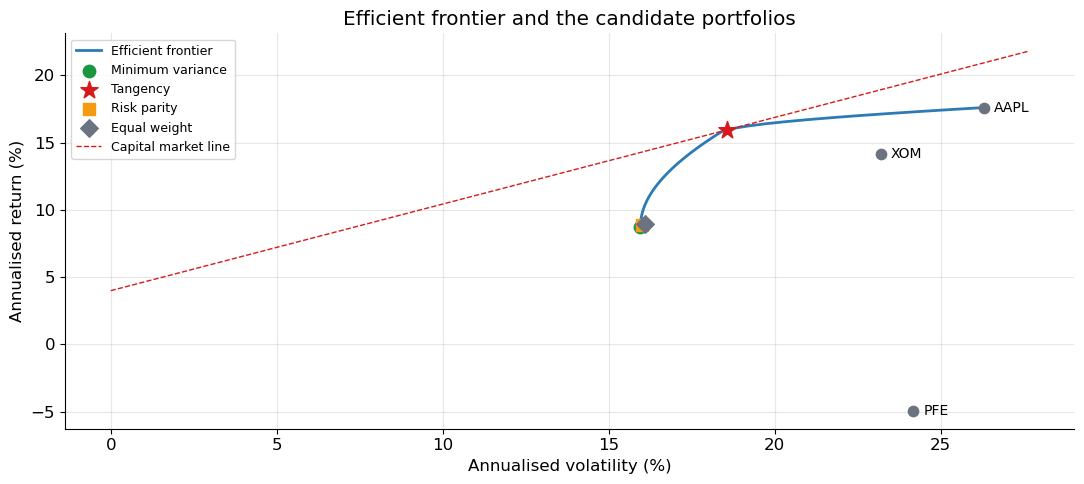

In [2]:
def optimise(expected, covariance, objective='max_sharpe', target=None,
             risk_aversion=None, constraint=None):
    frontier = EfficientFrontier(expected, covariance, weight_bounds=(0, 1))
    if constraint is not None:
        frontier.add_constraint(constraint)
    if objective == 'max_sharpe':
        frontier.max_sharpe(risk_free_rate=RF)
    elif objective == 'min_volatility':
        frontier.min_volatility()
    elif objective == 'efficient_return':
        frontier.efficient_return(target_return=target)
    elif objective == 'max_quadratic_utility':
        frontier.max_quadratic_utility(risk_aversion=risk_aversion)
    cleaned = frontier.clean_weights()
    return np.array([cleaned[s] for s in STOCKS])

def port_return(w, m): return float(np.asarray(w) @ np.asarray(m))
def port_vol(w, S):    return float(np.sqrt(np.asarray(w) @ np.asarray(S) @ np.asarray(w)))
def sharpe(w, m, S):   return (port_return(w, m) - RF) / port_vol(w, S)

def risk_contributions(w, S):
    w = np.asarray(w, dtype=float)
    total = np.sqrt(w @ S @ w)
    return w * (S @ w / total)

def erc_objective(w, S):
    rc = risk_contributions(w, S)
    return np.sum((rc[:, None] - rc[None, :]) ** 2)

def equal_risk(S):
    result = minimize(erc_objective, np.ones(3) / 3, args=(S,), method='SLSQP',
                      bounds=[(0.0, 1.0)] * 3,
                      constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1.0},),
                      options={'maxiter': 1000, 'ftol': 1e-12})
    return result.x

Sv, mv = S_sample.values, mu.values
w_minvar = optimise(mu, S_sample, 'min_volatility')
w_tan    = optimise(mu, S_sample, 'max_sharpe')
w_erc    = equal_risk(Sv)

base_portfolios = {'Equal weight': W_EQ, 'Minimum variance': w_minvar,
                   'Tangency (max Sharpe)': w_tan, 'Risk parity (ERC)': w_erc}

print(f"{'portfolio':<24}{'AAPL':>8}{'PFE':>8}{'XOM':>8}{'return':>9}{'vol':>8}{'Sharpe':>8}")
for name, w in base_portfolios.items():
    print(f'{name:<24}' + ''.join(f'{x*100:>7.1f}%' for x in w) +
          f'{port_return(w, mv)*100:>8.2f}%{port_vol(w, Sv)*100:>7.2f}%{sharpe(w, mv, Sv):>8.3f}')

print(f"\nRisk contributions as a share of portfolio volatility:")
print(f"{'portfolio':<24}{'AAPL':>8}{'PFE':>8}{'XOM':>8}{'spread':>10}")
for name, w in base_portfolios.items():
    rc = risk_contributions(w, Sv); rc = rc / rc.sum()
    print(f'{name:<24}' + ''.join(f'{x*100:>7.1f}%' for x in rc) +
          f'{(rc.max()-rc.min())*100:>9.1f}pp')

targets  = np.linspace(port_return(w_minvar, mv), mv.max() - 1e-6, 60)
frontier = [(port_vol(optimise(mu, S_sample, 'efficient_return', target=t), Sv), t)
            for t in targets]
fx, fy   = zip(*frontier)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(np.array(fx)*100, np.array(fy)*100, color=BLUE, lw=2, label='Efficient frontier')
for s in STOCKS:
    ax.scatter(np.sqrt(S_sample.loc[s, s])*100, mu[s]*100, color=GREY, s=55, zorder=3)
    ax.annotate(s, (np.sqrt(S_sample.loc[s, s])*100, mu[s]*100),
                textcoords='offset points', xytext=(7, -3), fontsize=10)
marks = [('Minimum variance', w_minvar, GREEN, 'o'), ('Tangency', w_tan, RED, '*'),
         ('Risk parity', w_erc, GOLD, 's'), ('Equal weight', W_EQ, GREY, 'D')]
for name, w, colour, marker in marks:
    ax.scatter(port_vol(w, Sv)*100, port_return(w, mv)*100, color=colour,
               s=170 if marker == '*' else 80, marker=marker, zorder=4, label=name)
cml_x = np.linspace(0, max(fx)*1.05, 50)
ax.plot(cml_x*100, (RF + sharpe(w_tan, mv, Sv)*cml_x)*100, color=RED, ls='--', lw=1,
        label='Capital market line')
ax.set_xlabel('Annualised volatility (%)'); ax.set_ylabel('Annualised return (%)')
ax.set_title('Efficient frontier and the candidate portfolios'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** My three names barely move together, with correlations of 0.181, 0.110 and 0.130. That pulls minimum variance to 15.96% volatility, below the 26.32%, 24.18% and 23.21% they run alone. Tangency drops PFE and splits 52.0% AAPL against 48.0% XOM, lifting Sharpe from 0.308 to 0.644. That is not skill. PFE lost 4.92% a year, and any optimiser handed a negative mean and a long-only constraint zeroes it.

Risk parity surprised me at 30.9/33.3/35.8, basically equal weight, with a 0.305 Sharpe against the 0.308 for splitting three ways. It is meant to stop the jumpiest stock dominating, but mine are all about as jumpy as each other. Tangency instead runs a 59.2pp risk-contribution spread with AAPL supplying 59.2% of the risk, so my best Sharpe is the least diversified thing on the page.

## 2 · Black-Litterman

Market caps are shares outstanding times the close on 30 June 2026, and risk aversion comes from my own cap-weighted portfolio rather than the textbook 2.5. My relative view gives AAPL 3 points a year over XOM, backing a platform earnings base over a cyclical energy margin, and the absolute view puts PFE at 5%, a partial recovery as its pipeline steadies rather than a repeat of its sample loss. The confidence on each is the proportional prior at tau = 0.05, scaling with the volatility of the portfolio expressing it.

Cap-weighted portfolio: return 16.65%, vol 23.28%  ->  implied risk aversion delta = 2.33
View uncertainty (standard deviation): view 1 7.5%, view 2 5.4%

        cap weight  equilibrium  historical  posterior
AAPL         86.3%       13.55%      17.61%     11.50%
PFE           2.6%        2.07%      -4.92%      3.48%
XOM          11.1%        2.40%      14.16%      4.39%

portfolio                   AAPL     PFE     XOM   return     vol  Sharpe
Market cap weights         86.3%    2.6%   11.1%   16.65%  23.28%   0.543
Black-Litterman            66.2%   11.4%   22.4%   14.27%  19.47%   0.527
Tangency on history        52.0%    0.0%   48.0%   15.96%  18.58%   0.644


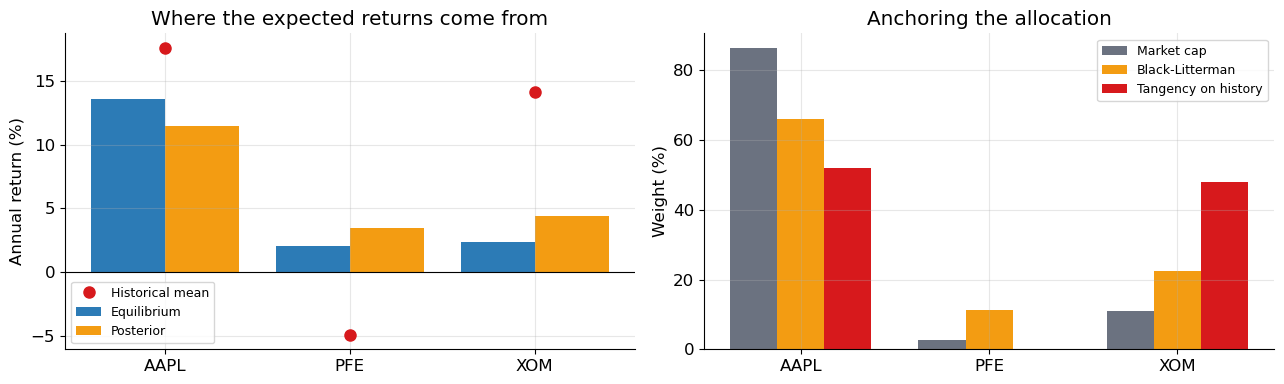

In [3]:
TAU = 0.05
P = pd.DataFrame([[1, 0, -1], [0, 1, 0]], columns=STOCKS)
Q = pd.Series([0.03, 0.05])

r_mkt = (rets * w_mkt.values).sum(axis=1)
delta = (r_mkt.mean()*252 - RF) / (r_mkt.std()**2 * 252)

def implied_returns(risk_aversion, sigma, w):
    equilibrium = risk_aversion * sigma.dot(w).squeeze()
    equilibrium.name = 'implied'
    return equilibrium

def proportional_prior(sigma, tau, p):
    helit = p.dot(tau * sigma).dot(p.T)
    return pd.DataFrame(np.diag(np.diag(helit.values)), index=p.index, columns=p.index)

def black_litterman(w_prior, sigma_prior, p, q, omega, risk_aversion, tau):
    pi  = implied_returns(risk_aversion, sigma_prior, w_prior)
    sps = tau * sigma_prior
    posterior_mu = pi + sps.dot(p.T).dot(
        inv(p.dot(sps).dot(p.T) + omega).dot(q - p.dot(pi).values))
    posterior_sigma = sigma_prior + sps - sps.dot(p.T).dot(
        inv(p.dot(sps).dot(p.T) + omega)).dot(p).dot(sps)
    return posterior_mu, posterior_sigma

omega   = proportional_prior(S_lw, TAU, P)
pi      = implied_returns(delta, S_lw, w_mkt)
mu_bl, S_bl = black_litterman(w_mkt, S_lw, P, Q, omega, delta, TAU)

w_bl = optimise(mu_bl, S_bl, 'max_quadratic_utility', risk_aversion=delta)

print(f'Cap-weighted portfolio: return {r_mkt.mean()*252*100:.2f}%, '
      f'vol {r_mkt.std()*np.sqrt(252)*100:.2f}%  ->  implied risk aversion delta = {delta:.2f}')
print(f'View uncertainty (standard deviation): '
      f'{", ".join(f"view {i+1} {np.sqrt(omega.values[i, i])*100:.1f}%" for i in range(2))}')
print(f"\n{'':6}{'cap weight':>12}{'equilibrium':>13}{'historical':>12}{'posterior':>11}")
for s in STOCKS:
    print(f'{s:6}{w_mkt[s]*100:>11.1f}%{pi[s]*100:>12.2f}%{mu[s]*100:>11.2f}%{mu_bl[s]*100:>10.2f}%')

print(f"\n{'portfolio':<24}{'AAPL':>8}{'PFE':>8}{'XOM':>8}{'return':>9}{'vol':>8}{'Sharpe':>8}")
for name, w in [('Market cap weights', w_mkt.values), ('Black-Litterman', w_bl),
                ('Tangency on history', w_tan)]:
    print(f'{name:<24}' + ''.join(f'{x*100:>7.1f}%' for x in w) +
          f'{port_return(w, mv)*100:>8.2f}%{port_vol(w, Sv)*100:>7.2f}%{sharpe(w, mv, Sv):>8.3f}')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(3)
axL.bar(x - 0.2, pi.values*100, 0.4, color=BLUE, label='Equilibrium')
axL.bar(x + 0.2, mu_bl.values*100, 0.4, color=GOLD, label='Posterior')
axL.plot(x, mu.values*100, 'o', color=RED, ms=8, label='Historical mean')
axL.axhline(0, color='black', lw=0.8)
axL.set_xticks(x); axL.set_xticklabels(STOCKS); axL.set_ylabel('Annual return (%)')
axL.set_title('Where the expected returns come from'); axL.legend(fontsize=9)
axR.bar(x - 0.25, w_mkt.values*100, 0.25, color=GREY, label='Market cap')
axR.bar(x,        w_bl*100,         0.25, color=GOLD, label='Black-Litterman')
axR.bar(x + 0.25, w_tan*100,        0.25, color=RED,  label='Tangency on history')
axR.set_xticks(x); axR.set_xticklabels(STOCKS); axR.set_ylabel('Weight (%)')
axR.set_title('Anchoring the allocation'); axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** My equilibrium returns are 13.55%, 2.07% and 2.40%, against historical means of 17.61%, -4.92% and 14.16%. They are never negative and they rank by market weight, so AAPL leads on 86.3% of the cap. Risk aversion of 2.33 falls out of my own data, close to the usual 2.5.

I was surprised my relative view came out bearish. Three points looks like a positive call on AAPL, but equilibrium already had AAPL at 13.55% against XOM at 2.40%, so stating it pulled AAPL down to 11.50% and pushed XOM to 4.39%. The absolute view lifted PFE only to 3.48%, short of the 5% I asserted, because its 5.4% uncertainty makes the posterior split the difference. The weights come out 66.2/11.4/22.4, between the market caps and something balanced, and that costs Sharpe, 0.527 against 0.644.

## 3 · Estimation error and a robust allocation

My robust portfolio resamples minimum variance, averaging the optimiser over 500 simulated histories from my own moments. The 1pp bump on a single mean separates real hypersensitivity from a plain change of inputs.

Same optimiser, different estimation window:
                              AAPL     PFE     XOM      estimated means
  tangency  full sample      52.0%    0.0%   48.0%      +17.6%, -4.9%, +14.2%
  tangency  first half       91.2%    0.0%    8.8%      +21.9%, -13.0%, +4.9%
  tangency  second half      16.1%    0.0%   83.9%      +13.3%, +3.2%, +23.4%
  min-var   full sample      27.4%   33.2%   39.4%
  min-var   first half       36.7%   24.2%   39.1%
  min-var   second half      19.8%   41.4%   38.9%
  risk par  full sample      30.9%   33.3%   35.8%
  risk par  first half       34.9%   29.2%   35.9%
  risk par  second half      28.4%   36.1%   35.5%

Sensitivity to a 1pp bump in a single expected return:
  AAPL +1pp      54.3%    0.0%   45.7%   largest weight shift 2.2pp
  PFE +1pp      52.0%    0.0%   48.0%   largest weight shift 0.0pp
  XOM +1pp      49.1%    0.0%   50.9%   largest weight shift 2.9pp



Resampled over 500 simulated histories:
portfolio                     AAPL     PFE     XOM
  Resampled tangency         48.9%    6.2%   44.8%
  Resampled min-variance     27.4%   33.3%   39.3%
  Shrinkage min-variance     29.4%   33.3%   37.3%
  Sample min-variance        27.4%   33.2%   39.4%
  Risk parity                30.9%   33.3%   35.8%

Draws where the tangency optimiser pushed a name below 1%: 459/500 = 91.8%


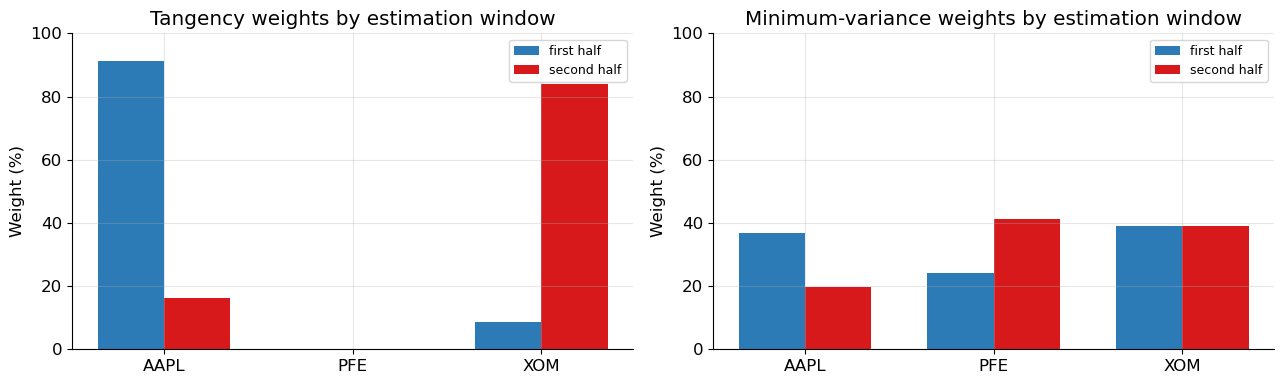

In [4]:
half  = len(rets) // 2
train, test = rets.iloc[:half], rets.iloc[half:]

def moments(sample):
    return (expected_returns.mean_historical_return(sample, returns_data=True, compounding=False),
            risk_models.sample_cov(sample, returns_data=True))

budget = ({'type': 'eq', 'fun': lambda w: w.sum() - 1.0},)
box    = [(0.0, 1.0)] * 3

def tangency_weights(m, S):
    negative_sharpe = lambda w: -(w @ m - RF) / np.sqrt(w @ S @ w)
    return minimize(negative_sharpe, np.ones(3)/3, method='SLSQP', bounds=box,
                    constraints=budget, options={'maxiter': 1000, 'ftol': 1e-14}).x

def minimum_variance_weights(S):
    return minimize(lambda w: w @ S @ w, np.ones(3)/3, method='SLSQP', bounds=box,
                    constraints=budget, options={'maxiter': 1000, 'ftol': 1e-14}).x

print('Same optimiser, different estimation window:')
print(f"{'':26}{'AAPL':>8}{'PFE':>8}{'XOM':>8}      estimated means")
for label, window in [('full sample', rets), ('first half', train), ('second half', test)]:
    m_w, S_w = moments(window)
    w_t = tangency_weights(m_w.values, S_w.values)
    print(f'  tangency  {label:<14}' + ''.join(f'{x*100:>7.1f}%' for x in w_t) +
          '      ' + ', '.join(f'{v*100:+.1f}%' for v in m_w))
for label, window in [('full sample', rets), ('first half', train), ('second half', test)]:
    m_w, S_w = moments(window)
    print(f'  min-var   {label:<14}' +
          ''.join(f'{x*100:>7.1f}%' for x in minimum_variance_weights(S_w.values)))
for label, window in [('full sample', rets), ('first half', train), ('second half', test)]:
    m_w, S_w = moments(window)
    print(f'  risk par  {label:<14}' +
          ''.join(f'{x*100:>7.1f}%' for x in equal_risk(S_w.values)))

print('\nSensitivity to a 1pp bump in a single expected return:')
for i, s in enumerate(STOCKS):
    bumped = mu.copy(); bumped.iloc[i] += 0.01
    w_b = optimise(bumped, S_sample, 'max_sharpe')
    print(f'  {s} +1pp   ' + ''.join(f'{x*100:>7.1f}%' for x in w_b) +
          f'   largest weight shift {np.abs(w_b - w_tan).max()*100:.1f}pp')

DRAWS = 500
rng = np.random.default_rng(42)
acc_minvar, acc_tan, cornered = np.zeros(3), np.zeros(3), 0
for _ in range(DRAWS):
    sim = rng.multivariate_normal(mv/252, Sv/252, size=len(rets))
    m_sim, S_sim = sim.mean(axis=0)*252, np.cov(sim, rowvar=False)*252
    w_sim = tangency_weights(m_sim, S_sim)
    acc_tan    += w_sim
    acc_minvar += minimum_variance_weights(S_sim)
    if w_sim.min() < 0.01:
        cornered += 1
w_robust    = acc_minvar / DRAWS
w_resamp_ms = acc_tan / DRAWS

print(f'\nResampled over {DRAWS} simulated histories:')
print(f"{'portfolio':<26}{'AAPL':>8}{'PFE':>8}{'XOM':>8}")
for name, w in [('Resampled tangency', w_resamp_ms), ('Resampled min-variance', w_robust),
                ('Shrinkage min-variance', optimise(mu, S_lw, 'min_volatility')),
                ('Sample min-variance', w_minvar), ('Risk parity', w_erc)]:
    print(f'  {name:<24}' + ''.join(f'{x*100:>7.1f}%' for x in w))
print(f'\nDraws where the tangency optimiser pushed a name below 1%: '
      f'{cornered}/{DRAWS} = {cornered/DRAWS:.1%}')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(3)
for i, (label, window, colour) in enumerate([('first half', train, BLUE),
                                             ('second half', test, RED)]):
    m_w, S_w = moments(window)
    axL.bar(x + (i-0.5)*0.35, tangency_weights(m_w.values, S_w.values)*100, 0.35,
            color=colour, label=label)
    axR.bar(x + (i-0.5)*0.35, minimum_variance_weights(S_w.values)*100, 0.35,
            color=colour, label=label)
for ax, title in [(axL, 'Tangency weights by estimation window'),
                  (axR, 'Minimum-variance weights by estimation window')]:
    ax.set_xticks(x); ax.set_xticklabels(STOCKS); ax.set_ylabel('Weight (%)')
    ax.set_ylim(0, 100); ax.set_title(title); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** Splitting my sample in half is brutal for tangency. First half it holds 91.2% AAPL and 8.8% XOM, second half 16.1% and 83.9%, the book flipping end to end on the same optimiser. Minimum variance moves less, 36.7% to 19.8% in AAPL, and risk parity least, because neither uses a mean.

The 1pp bump is where my data disagrees with the story that a one-point error moves weights ten or twenty points. Adding 1pp to AAPL moves my largest weight only 2.2pp, to XOM 2.9pp, and to PFE nothing, so the optimiser is not hypersensitive. What breaks it is that the estimate itself is enormous, AAPL's mean going from +21.9% to +13.3% between halves and XOM's from +4.9% to +23.4%. That is also why shrinkage does almost nothing, since with three assets and 750 days my covariance was never the problem. Resampling helps because it targets the mean, averaging tangency to 48.9/6.2/44.8 and putting PFE back, even though 91.8% of single draws still cornered a name. They corner different names, and averaging over that is what I would hold.

## 4 · ESG tilt

I could not source vendor ratings offline, so these are documented proxy scores I assigned, with the reasoning printed below. Rater A is environment-weighted, rewarding AAPL and marking XOM down for its reserves. Rater B is conduct-weighted, marking PFE down for litigation. Both run 0 to 100, higher better, and I tilt my Black-Litterman allocation since that is what I would otherwise hold.

           company  rater_A  rater_B
ticker                              
AAPL         Apple       82       58
PFE         Pfizer       61       47
XOM     ExxonMobil       24       55

AAPL A 82  Operations run on renewable power with a 2030 supply-chain carbon-neutral pledge; low direct emissions for its size
AAPL B 58  Repeated supply-chain labour and sourcing controversies; concentrated single-region manufacturing dependence

PFE A 61  Moderate direct footprint for a manufacturer; no fossil reserves but energy-intensive production sites
PFE B 47  Large historical litigation and marketing-conduct record including the 2009 off-label settlement; pricing-practice scrutiny

XOM A 24  Fossil-fuel producer carrying reserve-based transition exposure and large financed Scope 3 emissions
XOM B 55  Long-established board and disclosure practices; controversy record concentrated in climate litigation rather than conduct

Rank correlation between the two raters: 0.50
Rater A ranks: AAPL > PFE >

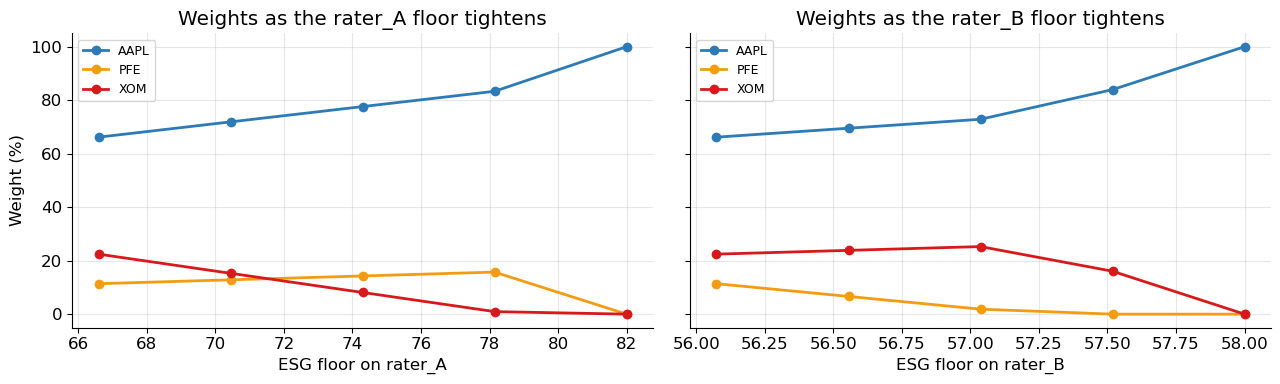

In [5]:
esg = pd.read_csv('a3_esg_scores.csv', index_col='ticker').loc[STOCKS]
print(esg[['company', 'rater_A', 'rater_B']].to_string())
for t in STOCKS:
    print(f'\n{t} A {esg.loc[t, "rater_A"]}  {esg.loc[t, "basis_A"]}')
    print(f'{t} B {esg.loc[t, "rater_B"]}  {esg.loc[t, "basis_B"]}')
rank_corr = spearmanr(esg.rater_A, esg.rater_B).statistic
print(f'\nRank correlation between the two raters: {rank_corr:.2f}')
print(f'Rater A ranks: {" > ".join(esg.rater_A.sort_values(ascending=False).index)}')
print(f'Rater B ranks: {" > ".join(esg.rater_B.sort_values(ascending=False).index)}')

base_sharpe = sharpe(w_bl, mv, Sv)

esg_paths = {}
for rater in ['rater_A', 'rater_B']:
    scores    = esg[rater].values
    start_sc  = float(w_bl @ scores)
    best_sc   = scores.max()
    print(f'\n{rater}: my allocation scores {start_sc:.1f}, best attainable {best_sc}')
    print(f"  {'floor':>7}{'AAPL':>8}{'PFE':>8}{'XOM':>8}{'return':>9}{'vol':>8}"
          f"{'Sharpe':>8}{'vs base':>9}")
    rows = []
    for step in [0.0, 0.25, 0.50, 0.75, 1.0]:
        floor = start_sc + step * (best_sc - start_sc)
        w_e = optimise(mu_bl, S_bl, 'max_quadratic_utility', risk_aversion=delta,
                       constraint=(lambda w, sc=scores, f=floor: w @ sc >= f))
        sh = sharpe(w_e, mv, Sv)
        rows.append((floor, w_e, sh))
        print(f'  {floor:>7.1f}' + ''.join(f'{x*100:>7.1f}%' for x in w_e) +
              f'{port_return(w_e, mv)*100:>8.2f}%{port_vol(w_e, Sv)*100:>7.2f}%'
              f'{sh:>8.3f}{sh - base_sharpe:>+9.3f}')
    esg_paths[rater] = rows


fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, rater, colour in [(axes[0], 'rater_A', GREEN), (axes[1], 'rater_B', BLUE)]:
    floors  = [r[0] for r in esg_paths[rater]]
    weights = np.array([r[1] for r in esg_paths[rater]]) * 100
    for j, s in enumerate(STOCKS):
        ax.plot(floors, weights[:, j], 'o-', lw=2, label=s,
                color=[BLUE, GOLD, RED][j])
    ax.set_xlabel(f'ESG floor on {rater}'); ax.set_title(f'Weights as the {rater} floor tightens')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Weight (%)')
plt.tight_layout(); plt.show()

**Interpretation:** My two raters agree on AAPL and disagree on everything else, with a rank correlation of 0.50. Rater A orders them AAPL > PFE > XOM and rater B AAPL > XOM > PFE, so the bottom two swap, as real providers do.

The consequence is sharper than I expected. Tightening the rater A floor from 66.6 to 78.1 cuts XOM from 22.4% to 0.9%, while tightening rater B from 56.1 to 57.0 cuts PFE to 1.9% as XOM rises to 25.3%. Same constraint, and the two raters tell me to sell opposite names. The cost flips too, from 0.527 down to 0.437 on rater A but up to 0.593 on rater B. So whether an ESG screen is expensive is not about ESG, it is about which provider I signed up with, and a 0.50 correlation makes that close to a coin flip. At the maximum floor both collapse to 100% AAPL, so a screen tight enough to bind on three names is a concentration decision, not a tilt.

## 5 · Scenario stress testing

Each scenario is a market move through beta plus a firm-specific overlay. Severely adverse is a broad equity shock, the climate transition puts a carbon price and stranded reserves on XOM, and the policy shock pairs drug-pricing reform with tariffs. The historical window is the worst 20-day stretch my book ever had.

AAPL  beta 1.127  (t = 23.0, R-squared 0.414)


PFE  beta 0.386  (t = 6.8, R-squared 0.058)
XOM  beta 0.238  (t = 4.3, R-squared 0.024)

Per-stock shocks (beta times the market move, plus the overlay):
                        AAPL   PFE   XOM
Severely adverse       -28.2  -9.7  -6.0
Climate transition     -18.9  -7.8 -28.6
Drug pricing + tariffs -21.0 -23.1   1.1

Worst 20-day window for the equal-weight book: 2025-03-12 to 2025-04-08
  cumulative -15.26%, worst single day -6.64%
  per stock: AAPL -21.9%, PFE -16.0%, XOM -7.7%

                          1-day VaR99  1-day ES97.5   ann vol
Normal times                    2.42%         2.89%    16.08%
Stress window                   6.40%         6.64%    34.22%
Ratio                           2.64x         2.30x     2.13x

Equal-weight book under each scenario, risk re-measured at 2.13x normal volatility spread over 20 days:
                                P&L  vs VaR99    VaR99   ES97.5  vs normal
  Severely adverse          -14.59%      6.0x    5.96%    6.96%      2.46x
  Climate t

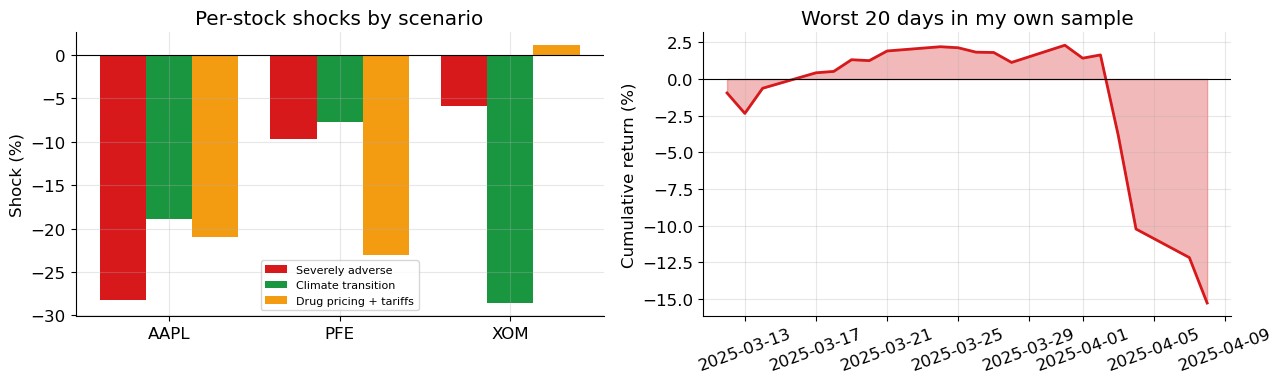

In [6]:
betas = {}
for s in STOCKS:
    aligned = sm.add_constant(mkt).join(rets[s]).dropna()
    fit = sm.OLS(aligned[s], aligned[['const', BENCH]]).fit()
    betas[s] = fit.params[BENCH]
    print(f'{s}  beta {fit.params[BENCH]:.3f}  (t = {fit.tvalues[BENCH]:.1f}, '
          f'R-squared {fit.rsquared:.3f})')
betas = pd.Series(betas)

SCENARIOS = {
    'Severely adverse':    (-0.25, {'AAPL':  0.00, 'PFE':  0.00, 'XOM':  0.00}),
    'Climate transition':  (-0.15, {'AAPL': -0.02, 'PFE': -0.02, 'XOM': -0.25}),
    'Drug pricing + tariffs': (-0.08, {'AAPL': -0.12, 'PFE': -0.20, 'XOM':  0.03}),
}
shock_table = pd.DataFrame({name: {s: betas[s]*market + overlay[s] for s in STOCKS}
                            for name, (market, overlay) in SCENARIOS.items()}).T[STOCKS]

rolling20 = port_eq.rolling(20).sum()
window_end   = rolling20.idxmin()
window_start = port_eq.index[port_eq.index.get_loc(window_end) - 19]
window_rets  = rets.loc[window_start:window_end]
hist_shock   = (1 + window_rets).prod() - 1

print(f'\nPer-stock shocks (beta times the market move, plus the overlay):')
print(shock_table.mul(100).round(1).to_string())
print(f'\nWorst 20-day window for the equal-weight book: '
      f'{window_start.date()} to {window_end.date()}')
print(f'  cumulative {(((1 + (window_rets * W_EQ).sum(axis=1)).prod()) - 1)*100:.2f}%, '
      f'worst single day {(window_rets * W_EQ).sum(axis=1).min()*100:.2f}%')
print('  per stock: ' + ', '.join(f'{s} {hist_shock[s]*100:+.1f}%' for s in STOCKS))

window_port = (window_rets * W_EQ).sum(axis=1)
stress_var  = -np.percentile(window_port, 1)
stress_es   = -window_port[window_port <= np.percentile(window_port, 2.5)].mean()
print(f'\n{"":24}{"1-day VaR99":>13}{"1-day ES97.5":>14}{"ann vol":>10}')
print(f'{"Normal times":24}{var99*100:>12.2f}%{es975*100:>13.2f}%'
      f'{port_eq.std()*np.sqrt(252)*100:>9.2f}%')
print(f'{"Stress window":24}{stress_var*100:>12.2f}%{stress_es*100:>13.2f}%'
      f'{window_port.std()*np.sqrt(252)*100:>9.2f}%')
print(f'{"Ratio":24}{stress_var/var99:>12.2f}x{stress_es/es975:>13.2f}x'
      f'{window_port.std()/port_eq.std():>9.2f}x')

vol_multiple = window_port.std() / port_eq.std()
horizon = len(window_port)
centred = port_eq - port_eq.mean()

print(f'\nEqual-weight book under each scenario, risk re-measured at '
      f'{vol_multiple:.2f}x normal volatility spread over {horizon} days:')
print(f'  {"":24}{"P&L":>9}{"vs VaR99":>10}{"VaR99":>9}{"ES97.5":>9}{"vs normal":>11}')
for name in list(SCENARIOS) + ['Historical replay']:
    shock = hist_shock if name == 'Historical replay' else shock_table.loc[name]
    pnl = float(shock @ W_EQ)
    stressed = pnl / horizon + centred * vol_multiple
    scenario_var = -np.percentile(stressed, 1)
    scenario_es = -stressed[stressed <= np.percentile(stressed, 2.5)].mean()
    print(f'  {name:<24}{pnl*100:>8.2f}%{abs(pnl)/var99:>9.1f}x'
          f'{scenario_var*100:>8.2f}%{scenario_es*100:>8.2f}%{scenario_var/var99:>10.2f}x')
print(f'  {"Normal times":<24}{"":>9}{"":>10}{var99*100:>8.2f}%{es975*100:>8.2f}%'
      f'{1.0:>10.2f}x')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(3)
for i, name in enumerate(SCENARIOS):
    axL.bar(x + (i-1)*0.27, shock_table.loc[name]*100, 0.27,
            color=[RED, GREEN, GOLD][i], label=name)
axL.axhline(0, color='black', lw=0.8)
axL.set_xticks(x); axL.set_xticklabels(STOCKS); axL.set_ylabel('Shock (%)')
axL.set_title('Per-stock shocks by scenario'); axL.legend(fontsize=8)
cum = (1 + window_port).cumprod() - 1
axR.fill_between(cum.index, cum*100, color=RED, alpha=0.3)
axR.plot(cum.index, cum*100, color=RED, lw=2)
axR.axhline(0, color='black', lw=0.8)
axR.set_ylabel('Cumulative return (%)'); axR.tick_params(axis='x', rotation=20)
axR.set_title(f'Worst 20 days in my own sample')
plt.tight_layout(); plt.show()

**Interpretation:** My betas do most of the work and they are very unequal. AAPL is 1.127 (R-squared 0.414), XOM only 0.238 (0.024), so 98% of what moves XOM is not the market. A 25% market fall takes XOM down just 6.0%, so anything that threatens it has to come through the overlay, which is why I design scenarios, not factor shocks.

Climate transition is my worst case at -18.42%, beating the severely adverse -14.59% on a smaller market shock, because a concentrated hit on the name with least market exposure does more than a broad one. My worst actual 20 days ran 12 March to 8 April 2025 and cost 15.26%, so my scenarios are severe without being fantasy. Inside that window my 1-day 99% VaR is 6.40% against 2.42% normally, so a scenario costs twice, moving the book 5.9 to 7.6 times my daily VaR and leaving the VaR itself near 6%.

These do not capture system-wide stress. Each is one market move plus independent firm overlays, so the only thing linking my stocks is beta, and XOM's is 0.238. That cannot produce the 0.689 crisis correlation I measure in my worst 20 days, the correlated failure macroprudential regulation exists for.

## 6 · Systemic risk, contagion and model risk

Delta-CoVaR asks how much deeper the market's 5% tail gets when a name is at its own 5% tail. I also split the sample by how bad the market day was, because my whole frontier rests on low correlations holding up.

CoVaR of the index conditional on each stock (quantile regression at 5%):
      stock VaR5 %  quantile beta  CoVaR distress %  CoVaR normal %  Delta-CoVaR %
AAPL        -2.534          0.393            -2.136          -1.095         -1.041
PFE         -2.339          0.168            -1.747          -1.357         -0.390
XOM         -2.381          0.152            -1.789          -1.414         -0.375

Marginal expected shortfall on the market's worst 5% of days (38 days, threshold -1.46%):
  AAPL  -2.358%
  PFE  -1.002%
  XOM  -0.818%

Correlation on the market's worst decile (75 days) vs the rest:
  calm   average pairwise 0.060
       AAPL    PFE    XOM
AAPL  1.000  0.102  0.001
PFE   0.102  1.000  0.076
XOM   0.001  0.076  1.000
  crisis average pairwise 0.423
       AAPL    PFE    XOM
AAPL  1.000  0.353  0.542
PFE   0.353  1.000  0.373
XOM   0.542  0.373  1.000

Also in the worst 20-day window: average pairwise 0.689
Equal-weight annualised volatility: calm 14.3%, crisis 22.0%


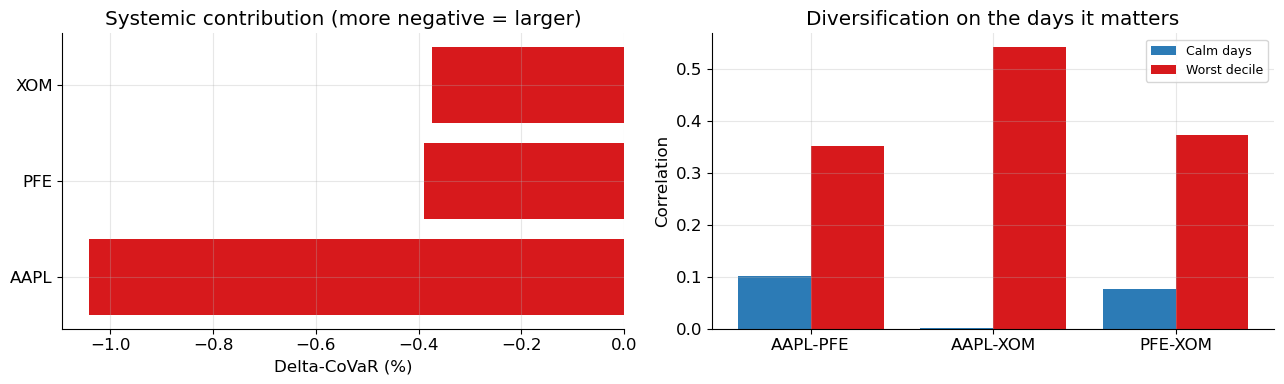

In [7]:
ALPHA = 0.05
covar_rows = {}
for s in STOCKS:
    common = rets[s].dropna().index.intersection(mkt.dropna().index)
    y, X = mkt.loc[common].values, rets[s].loc[common].values
    fit = QuantReg(y, np.column_stack([np.ones(len(X)), X])).fit(q=ALPHA, max_iter=5000)
    intercept, slope = fit.params
    covar_distress = intercept + slope * np.percentile(X, ALPHA*100)
    covar_normal   = intercept + slope * np.median(X)
    covar_rows[s] = {'stock VaR5 %': np.percentile(X, ALPHA*100)*100,
                     'quantile beta': slope,
                     'CoVaR distress %': covar_distress*100,
                     'CoVaR normal %': covar_normal*100,
                     'Delta-CoVaR %': (covar_distress - covar_normal)*100}
covar_df = pd.DataFrame(covar_rows).T
print('CoVaR of the index conditional on each stock (quantile regression at 5%):')
print(covar_df.round(3).to_string())

market_tail = np.percentile(mkt, 5)
tail_days = mkt[mkt <= market_tail]
print(f'\nMarginal expected shortfall on the market\'s worst 5% of days '
      f'({len(tail_days)} days, threshold {market_tail*100:.2f}%):')
for s in STOCKS:
    print(f'  {s}  {rets[s].loc[tail_days.index].mean()*100:.3f}%')

decile   = np.percentile(mkt, 10)
crisis   = rets.loc[mkt[mkt <= decile].index]
calm     = rets.loc[mkt[mkt > decile].index]
def average_pairwise(c):
    v = c.values
    return (v[0, 1] + v[0, 2] + v[1, 2]) / 3
print(f'\nCorrelation on the market\'s worst decile ({len(crisis)} days) vs the rest:')
print(f'  calm   average pairwise {average_pairwise(calm.corr()):.3f}')
print(calm.corr().round(3).to_string())
print(f'  crisis average pairwise {average_pairwise(crisis.corr()):.3f}')
print(crisis.corr().round(3).to_string())
print(f'\nAlso in the worst 20-day window: average pairwise '
      f'{average_pairwise(window_rets.corr()):.3f}')
print(f'Equal-weight annualised volatility: calm '
      f'{(calm * W_EQ).sum(axis=1).std()*np.sqrt(252)*100:.1f}%, crisis '
      f'{(crisis * W_EQ).sum(axis=1).std()*np.sqrt(252)*100:.1f}%')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
axL.barh(STOCKS, covar_df['Delta-CoVaR %'].values, color=RED)
axL.set_xlabel('Delta-CoVaR (%)'); axL.set_title('Systemic contribution (more negative = larger)')
labels = ['AAPL-PFE', 'AAPL-XOM', 'PFE-XOM']
calm_c   = [calm.corr().values[0,1], calm.corr().values[0,2], calm.corr().values[1,2]]
crisis_c = [crisis.corr().values[0,1], crisis.corr().values[0,2], crisis.corr().values[1,2]]
x = np.arange(3)
axR.bar(x - 0.2, calm_c, 0.4, color=BLUE, label='Calm days')
axR.bar(x + 0.2, crisis_c, 0.4, color=RED, label='Worst decile')
axR.set_xticks(x); axR.set_xticklabels(labels); axR.set_ylabel('Correlation')
axR.set_title('Diversification on the days it matters'); axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** AAPL is my systemic name and it is not close. Its Delta-CoVaR is -1.041% against -0.390% for PFE and -0.375% for XOM, so when AAPL is at its own 5% tail the index tail deepens nearly three times as much. Yet all three have almost identical standalone risk, own 5% VaRs of -2.53%, -2.34% and -2.38%, so volatility alone would rank them equal. Marginal expected shortfall agrees, AAPL losing 2.358% on the market's worst days against 0.818% for XOM.

Then the correlations undo much of what came before. On calm days my average pairwise correlation is 0.060, but on the worst market decile it is 0.423, and in my worst 20-day window it reaches 0.689, book volatility rising from 14.3% to 22.0%. All three fall together on exactly the days I need them not to, so the low correlations my frontier leaned on are only a calm-market property. That is also where my models fail. The quantile regression is linear, assuming the same tail slope in a crash as on an ordinary day, on a 5% quantile resting on only 38 of my 750 days.

## 7 · Resilience, the out-of-sample test and what I would actually hold

Every portfolio is rebuilt from scratch on the training half, prior and ESG floor included, so nothing from the test period leaks in.

portfolio                 AAPL     PFE     XOM  Severely adverse           Climate      Policy shock        Historical
Equal weight             33.3%   33.3%   33.3%           -14.59%           -18.42%           -14.34%           -15.19%
Minimum variance         27.4%   33.2%   39.4%           -13.27%           -19.02%           -13.00%           -14.34%
Tangency                 52.0%    0.0%   48.0%           -17.52%           -23.54%           -10.41%           -15.10%
Black-Litterman          66.2%   11.4%   22.4%           -21.08%           -19.81%           -16.29%           -18.05%
Risk parity              30.9%   33.3%   35.8%           -14.05%           -18.67%           -13.78%           -14.84%
Robust (resampled)       27.4%   33.3%   39.3%           -13.27%           -19.01%           -13.01%           -14.34%
ESG-constrained          77.6%   14.3%    8.1%           -23.73%           -18.10%           -19.52%           -19.92%

Most resilient on its own worst case: Equal wei


Out-of-sample: weights fitted on 2023-07-05 to 2024-12-27, scored on 2024-12-30 to 2026-06-30
portfolio                return     vol  Sharpe   max DD   vs 1/N  turnover
Equal weight             13.31%  18.46%   0.504  -19.51%   +0.000     0.00
Minimum variance         14.81%  18.88%   0.573  -19.49%   +0.069     0.34
Tangency                 14.23%  28.28%   0.362  -29.40%   -0.143     1.50
Black-Litterman          14.76%  23.08%   0.466  -24.49%   -0.038     0.12
Risk parity              13.98%  18.61%   0.537  -19.51%   +0.032     0.14
Robust (resampled)       14.84%  18.89%   0.574  -19.50%   +0.069     0.35
ESG-constrained          13.02%  25.47%   0.354  -27.39%   -0.150     0.12

Beat 1/N out of sample: Minimum variance, Risk parity, Robust (resampled)


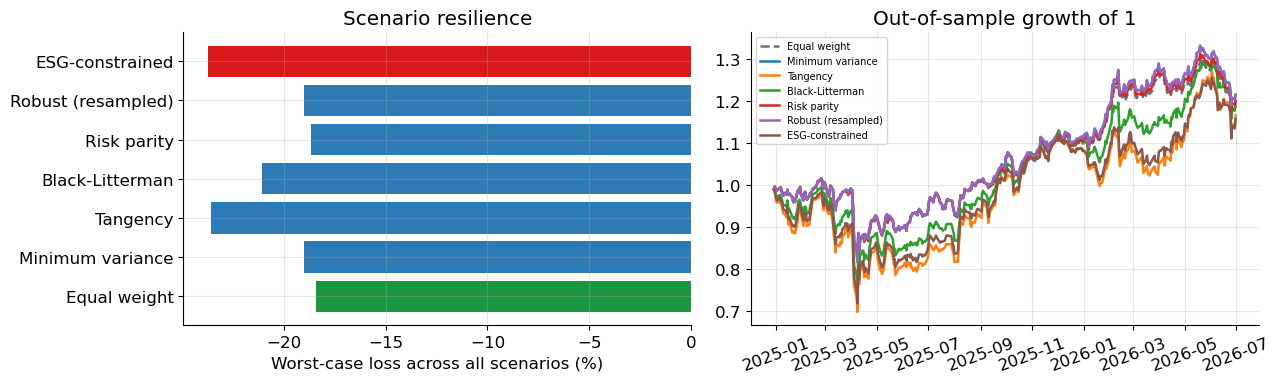

In [8]:
def build_portfolios(sample):
    m, S_s = moments(sample)
    S_shrunk = risk_models.CovarianceShrinkage(sample, returns_data=True).ledoit_wolf()
    r_m = (sample * w_mkt.values).sum(axis=1)
    d   = (r_m.mean()*252 - RF) / (r_m.std()**2 * 252)
    m_bl, S_b = black_litterman(w_mkt, S_shrunk, P, Q,
                                proportional_prior(S_shrunk, TAU, P), d, TAU)
    utility = lambda constraint=None: optimise(m_bl, S_b, 'max_quadratic_utility',
                                               risk_aversion=d, constraint=constraint)
    gen = np.random.default_rng(42)
    accumulated = np.zeros(3)
    for _ in range(500):
        sim = pd.DataFrame(gen.multivariate_normal(m.values/252, S_s.values/252,
                                                   size=len(sample)), columns=STOCKS)
        accumulated += optimise(*moments(sim), 'min_volatility')
    floor_a = float(utility() @ esg.rater_A.values)
    floor_a += 0.50 * (esg.rater_A.max() - floor_a)
    return {'Equal weight': W_EQ,
            'Minimum variance': optimise(m, S_s, 'min_volatility'),
            'Tangency': optimise(m, S_s, 'max_sharpe'),
            'Black-Litterman': utility(),
            'Risk parity': equal_risk(S_s.values),
            'Robust (resampled)': accumulated / 500,
            'ESG-constrained': utility(lambda w: w @ esg.rater_A.values >= floor_a)}

candidates = build_portfolios(rets)
columns = ['Severely adverse', 'Climate', 'Policy shock', 'Historical']
print(f"{'portfolio':<22}{'AAPL':>8}{'PFE':>8}{'XOM':>8}" +
      ''.join(f'{c:>18}' for c in columns))
for name, w in candidates.items():
    losses = [float(shock_table.loc[k] @ w) for k in SCENARIOS] + [float(hist_shock @ w)]
    print(f'{name:<22}' + ''.join(f'{x*100:>7.1f}%' for x in w) +
          ''.join(f'{v*100:>17.2f}%' for v in losses))
worst = {name: min([float(shock_table.loc[k] @ w) for k in SCENARIOS] + [float(hist_shock @ w)])
         for name, w in candidates.items()}
print(f'\nMost resilient on its own worst case: '
      f'{max(worst, key=worst.get)} at {max(worst.values())*100:.2f}%')
print(f'Least resilient: {min(worst, key=worst.get)} at {min(worst.values())*100:.2f}%')

crisis_cov = crisis.cov() * 252
mu_bl_stress, S_bl_stress = black_litterman(w_mkt, crisis_cov, P, Q,
                                            proportional_prior(crisis_cov, TAU, P), delta, TAU)
stressed_reopt = {'Minimum variance': (w_minvar, optimise(mu, crisis_cov, 'min_volatility')),
                  'Tangency':         (w_tan,    optimise(mu, crisis_cov, 'max_sharpe')),
                  'Risk parity':      (w_erc,    equal_risk(crisis_cov.values)),
                  'Black-Litterman':  (w_bl,     optimise(mu_bl_stress, S_bl_stress,
                                                          'max_quadratic_utility', risk_aversion=delta))}
print('\nRe-optimising on my crisis-window covariance (base means held):')
print(f"{'portfolio':<20}{'base wt':>20}{'stressed wt':>22}{'move':>9}")
for name, (wb, ws) in stressed_reopt.items():
    move = np.abs(np.asarray(ws) - np.asarray(wb)).sum()
    print(f'{name:<20}' + '/'.join(f'{x*100:.0f}' for x in wb).rjust(19) +
          '  ' + '/'.join(f'{x*100:.0f}' for x in ws).rjust(20) + f'{move*100:>7.1f}pp')

trained = build_portfolios(train)
tested  = build_portfolios(test)
print(f'\nOut-of-sample: weights fitted on {train.index[0].date()} to '
      f'{train.index[-1].date()}, scored on {test.index[0].date()} to {test.index[-1].date()}')
print(f"{'portfolio':<22}{'return':>9}{'vol':>8}{'Sharpe':>8}{'max DD':>9}{'vs 1/N':>9}{'turnover':>10}")
oos = {}
for name, w in trained.items():
    r = (test * w).sum(axis=1)
    ann_r, ann_v = r.mean()*252, r.std()*np.sqrt(252)
    cumulative = (1 + r).cumprod()
    drawdown = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()
    turnover = np.abs(np.asarray(w) - np.asarray(tested[name])).sum()
    oos[name] = {'ret': ann_r, 'vol': ann_v, 'sharpe': (ann_r - RF)/ann_v,
                 'dd': drawdown, 'to': turnover}
for name, m_ in oos.items():
    print(f"{name:<22}{m_['ret']*100:>8.2f}%{m_['vol']*100:>7.2f}%{m_['sharpe']:>8.3f}"
          f"{m_['dd']*100:>8.2f}%{m_['sharpe']-oos['Equal weight']['sharpe']:>+9.3f}{m_['to']:>9.2f}")
beat = [n for n, m_ in oos.items() if m_['sharpe'] > oos['Equal weight']['sharpe']]
print(f'\nBeat 1/N out of sample: {", ".join(beat) if beat else "none"}')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
names = list(candidates)
axL.barh(names, [worst[n]*100 for n in names],
         color=[GREEN if worst[n] == max(worst.values()) else
                RED if worst[n] == min(worst.values()) else BLUE for n in names])
axL.set_xlabel('Worst-case loss across all scenarios (%)')
axL.set_title('Scenario resilience')
for name in names:
    axR.plot((1 + (test * trained[name]).sum(axis=1)).cumprod(), lw=1.8,
             color=GREY if name == 'Equal weight' else None,
             ls='--' if name == 'Equal weight' else '-', label=name)
axR.set_title('Out-of-sample growth of 1'); axR.legend(fontsize=7); axR.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Interpretation:** My two tests disagree, and that is the finding. On worst-case loss equal weight wins at -18.42%, ahead of risk parity at -18.67%, while Black-Litterman loses 21.08% and ESG 23.73%. Out of sample the order flips. Minimum variance and the resampled book reach 0.573 and 0.574 against 1/N's 0.504, risk parity 0.537, while tangency, Black-Litterman and ESG all lose, tangency at 0.362. So every construction that ignores expected returns beats 1/N and every one that uses them loses, the DeMiguel result on three stocks. Turnover says why. Re-estimating on the second half moves tangency 1.50 in absolute weight but risk parity only 0.14, and 1/N nothing, so the winners barely trade and the one estimation error sinks trades most.

Stress says the same. Minimum variance even loses to equal weight in my climate scenario, -19.02% against -18.42%, holding 39.4% XOM for low volatility when XOM carries my transition exposure. Re-optimising on my crisis-window covariance, minimum variance reshuffles 37.6pp and tangency 48.4pp while risk parity moves only 11.0pp, so the two that scored best are the least stable once the correlations I criticised change.

So I would hold risk parity, its 0.537 Sharpe near the best, barely trading and barely moving under stress, and needing no expected-return estimate. I would not hold my ESG version, which loses to 1/N. Against Basel III the shape is right and the depth is not, since I have the scenarios and losses but no capital stack and only one horizon, and every number came from one person running one set of code, so governance needs independent validation and a model inventory.